# Module 7 — Anomaly Detection on Instrument Telemetry

**สิ่งที่ต้องรู้ก่อนเรียนโมดูลนี้ (prerequisites):**
- จาก Day 1: เข้าใจ **distribution** (median, MAD, σ) และกฎ σ แบบ control chart (±3σ) จาก background notebooks — เราจะหยิบมาใช้เป็น detector ตัวแรก
- ความคุ้นเคยกับ polars / matplotlib ระดับอ่านโค้ดได้
- ไม่ต้องมีพื้นฐาน time-series forecasting — โมดูลนี้ยังไม่พยากรณ์ เราแค่ "ดูเฝ้า" ซีรีส์การวัด

เรื่องราวเชิงเมโทรโลยี: ซีรีส์นี้คือ **telemetry ของเซนเซอร์/โพรบที่ติดตั้งใช้งานจริง** — อุณหภูมิภายในเครื่องจักรอุตสาหกรรม วัดทุก 5 นาที นาน ~3 เดือน สิ่งที่ผู้ดูแลเครื่องมือวัดเจอจริงมีสามแบบ: **ดับ sudden** (shutdown), **หายไปนาน** (prolonged dropout) และ **คลาดช้า ๆ** (slow drift) — และแต่ละแบบจับยากไม่เท่ากัน คนเมโทรโลยีรู้จัก control chart อยู่แล้ว เราจะเริ่มจาก "พี่เลี้ยง" ของ Shewhart chart ก่อนพา ML เข้ามา

**Dataset ที่ใช้ (โปรดอ่านก่อนใช้งาน):**

In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

- *NAB `realKnownCause/machine_temperature_system_failure`* — Ahmad, S., Lavin, A., Purdy, S., Agha, Z. (2017). "Unsupervised real-time anomaly detection for streaming data", *Neurocomputing*, 262, 134–147. Data: Numenta Anomaly Benchmark (NAB), https://github.com/numenta/NAB (MIT License) — `datasets/machine_temperature_system_failure.csv`
- *labels* — มาจากไฟล์ `combined_windows.json` ของ NAB (repo เดียวกัน, MIT License) เก็บสำเนาไว้ที่ `datasets/nab_machine_temperature_labels.json` — labeled anomaly windows 4 ช่วง (shutdown/failure ที่ทีม NAB กำกับด้วยมือ)

## 1. โหลดซีรีส์และดูให้เห็นก่อน

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

df = pl.read_csv(DATA / "machine_temperature_system_failure.csv", try_parse_dates=True)
ts = df["timestamp"].to_numpy()
v = df["value"].to_numpy()

lab_windows = json.loads((DATA / "nab_machine_temperature_labels.json").read_text())[
    "realKnownCause/machine_temperature_system_failure.csv"
]
lab_mask = np.zeros(df.height, dtype=bool)
for a, b in lab_windows:
    lab_mask |= (ts >= np.datetime64(a)) & (ts <= np.datetime64(b))

print(f"rows = {df.height}, columns = {df.columns}")
print(f"ช่วงเวลา: {ts[0]} → {ts[-1]} (sampling 5 นาที)")
print(f"labeled anomaly windows = {len(lab_windows)}, จุดที่อยู่ในหน้าต่าง = {lab_mask.sum()}")

rows = 22695, columns = ['timestamp', 'value']
ช่วงเวลา: 2013-12-02T21:15:00.000000 → 2014-02-19T15:25:00.000000 (sampling 5 นาที)
labeled anomaly windows = 4, จุดที่อยู่ในหน้าต่าง = 2268


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPy

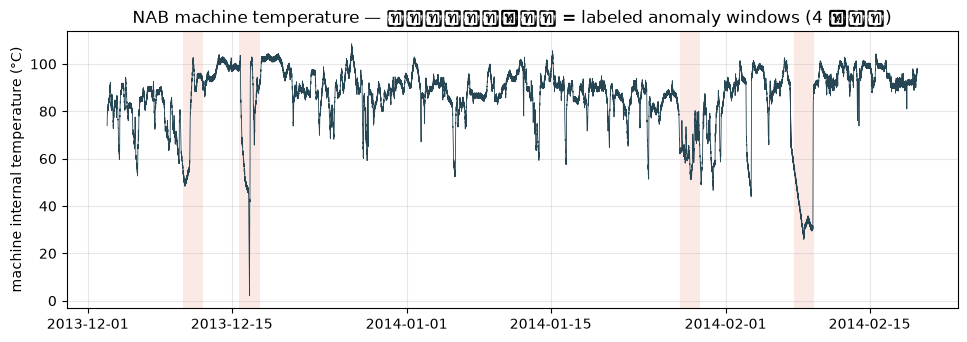

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 3.6))
for a, b in lab_windows:
    ax.axvspan(np.datetime64(a), np.datetime64(b), color="#e76f51", alpha=0.15, lw=0)
ax.plot(ts, v, color="#264653", lw=0.6)
ax.set_ylabel("machine internal temperature (°C)")
ax.set_title("NAB machine temperature — แถบแดงอ่อน = labeled anomaly windows (4 ช่วง)")
ax.grid(alpha=0.3)
plt.show()

อ่านภาพนี้ก่อนทำอะไรต่อ:

- **รูปทรงปกติ** ของเครื่องคืออุณหภูมิ ~85–92 °C แกว่ง ๆ รอบระดับเดียว — เหมือนเครื่องมือที่ "นิ่งดี" ในช่วงว่าง
- **ช่วงกลางเดือนธ.ค.** มีการด่วนลงลึกสองครั้ง (แถบแดงที่ 1–2): ครั้งแรกอุณหภูมิร่วงถึง ~48 °C, ครั้งที่สองร่วงถึง ~2 °C — shutdown แบบฉับพลัน
- **ปลายเดือน ม.ค.** (แถบแดงที่ 3) อุณหภูมิ **ไหลลงช้า ๆ** เป็นทางลาดยาวหลายชั่วโมงก่อนดับ — นี่คือตัวอย่างเงา ๆ ของ drift ที่เราจะกลับมาเจอตอนท้าย
- **ต้นเดือน ก.พ.** (แถบแดงที่ 4) เป็น dropout ยาว: ค่าตกแล้วแกว่งอยู่ระดับต่ำหลายสิบชั่วโมง

สังเกตด้วยว่า **นอกแถบแดง** ซีรีส์ก็มีพฤติกรรมหลากหลาย (สไปก์สั้น ๆ, ระดับที่ขยับ) — โลกจริงไม่ให้ "ปกติ" ที่สะอาดเหมือนตำรา

## 2. ภาษากลางก่อนลงมือ: anomaly มีสามชนิด

วรรณกรรม anomaly detection แบ่งเป็นสามชนิด — จำด้วยตัวอย่างจากกราฟข้างบนได้หมด:

| ชนิด | ความหมาย | ตัวอย่างในซีรีส์นี้ |
|---|---|---|
| **point anomaly** | จุดเดียวผิดปกติชัดเจนเทียบค่ารอบข้าง | สไปก์สูง ~108 °C กลางเดือนธ.ค. (ตอนต้นของแถบแดงที่ 2) |
| **contextual anomaly** | ค่าเดียวกัน "ปกติ" ในบริบทหนึ่ง แต่ผิดปกติในอีกบริบท | อุณหภูมิ ~75 °C เป็นค่าที่เครื่องพร้อมจะมีได้ แต่ถ้าโผล่ตอนที่ baseline นิ่งที่ 90 °C ติด ๆ กัน = ผิดปกติ |
| **collective anomaly** | ค่าแต่ละตัวไม่ผิดปกติเอง แต่ **ทั้งช่วงรวมกัน** ผิดปกติ | แถบแดงที่ 3: ค่าต่ำ ๆ ทีละจุดไม่แปลก แต่ทั้งทางลาดหลายชั่วโมง = เครื่องกำลังพัง |

และแยกอีกมิติด้วย "รูปแบบความผิดปกติ" ที่งานเมโทรโลยีเจอบ่อย:

- **sudden shift** — ระดับกระโดดทันที (เครื่องดับ, สวิตช์วงจร) → **จับง่ายสุด**
- **dropout** — สัญญาณหาย/ค้างต่ำนาน → จับได้ด้วยกฎระดับ ถ้า baseline ไม่ลากตาม
- **slow drift** — ค่าคลาดช้า ๆ ต่อเนื่อง (sensor aging, contamination) → **ยากสุด** เพราะทุกจุดดู "ใกล้เคียงเมื่อวาน" และ baseline แบบปรับตัวก็ไหลตามไปด้วย

หัวใจของโมดูลนี้: detector แต่ละตัวมีความถนัดต่างกัน เราจะพิสูจน์ด้วยข้อมูลจริงแล้วปิดท้ายด้วย drift — เคสที่ ML ทั่วไปพลาด

## 3. Rolling robust baseline — ญาติพี่น้องของ Shewhart chart

แนวคิดแรกไม่ใช่ ML เลย: **baseline เคลื่อนที่** แบบเดียวกับ control chart ที่ห้องสอบเทียบใช้อยู่แล้ว

- **Shewhart chart** คำนวณ mean ± 3σ จากช่วง baseline ที่ "นิ่ง" แล้วตั้งเป็น limit คงที่ — เหมาะเมื่อกระบวนการ stable
- ซีรีส์จริงของเราไม่ stable ตลอด (อุณหภูมิห้อง, โหลดเครื่องเปลี่ยน) เราจึงให้ baseline **เคลื่อนตามเวลา**: คำนวณจากหน้าต่างย้อนหลังเท่านั้น (trailing window)
- ใช้ **median และ MAD** แทน mean/σ เพราะ robust ต่อ outlier — ถ้าใช้ mean แล้ว anomaly โผล่ในหน้าต่าง baseline จะดึง limit ให้หนีไปตาม anomaly เอง
- สถิติที่ได้คือ **robust z-score**: `z = (x − rolling median) / (1.4826 × rolling MAD)` (ค่า 1.4826 ทำให้ MAD ปรับเป็นประมาณการของ σ เมื่อข้อมูลเป็น Gaussian)

เกณฑ์ตัดสิน: flag เมื่อ `|z| > 5` — หยาบกว่ากฎ ±3σ ของ Shewhart เพราะ baseline เราปรับตัวตลอด ค่า z จึงเบากว่าจริงในช่วงที่ซีรีส์แกว่งแรง

In [4]:
W = 144  # หน้าต่างย้อนหลัง 144 จุด = 12 ชั่วโมง (sampling 5 นาที)

s = df["value"]
roll_med = s.rolling_median(window_size=W, min_samples=W // 2)
roll_mad = (s - roll_med).abs().rolling_median(window_size=W, min_samples=W // 2) * 1.4826
robust_z = ((s - roll_med) / roll_mad).fill_null(0.0).fill_nan(0.0)

Z_THR = 5.0
z_flag = (robust_z.abs() > Z_THR).to_numpy()

ก่อนตีความ ให้นับผลแบบเดียวกันทุก detector เพื่อเทียบกันได้ตรง ๆ:

- **caught** — labeled window ถือว่า "จับได้" ถ้ามี detection อย่างน้อย 1 จุดตกในหน้าต่าง (overlap score แบบง่าย)
- **false alarms** — จำนวน detection ที่อยู่ **นอก** หน้าต่าง labeled ทั้งหมด

robust z |z|>5.0: จับได้ 3/4 windows | flags = 627 | false alarms = 473


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


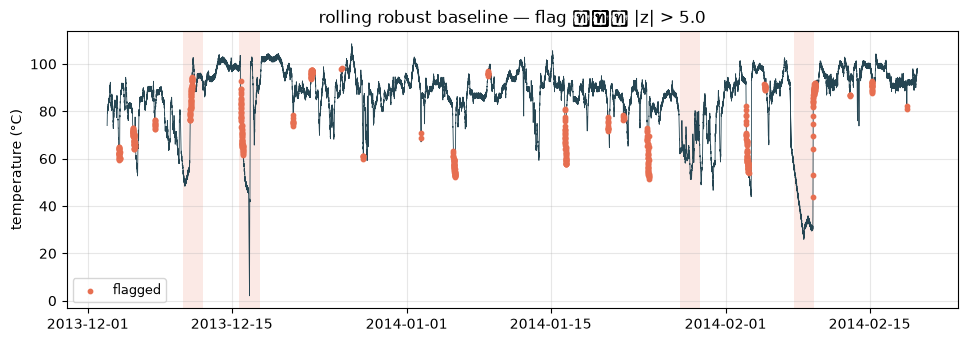

In [5]:
def evaluate(flag: np.ndarray, name: str) -> tuple[int, int]:
    """นับ labeled windows ที่ถูกจับ (overlap แบบง่าย) + false alarms นอกหน้าต่าง."""
    caught = sum(
        1 for a, b in lab_windows
        if (((ts >= np.datetime64(a)) & (ts <= np.datetime64(b))) & flag).any()
    )
    false_alarms = int((flag & ~lab_mask).sum())
    print(f"{name}: จับได้ {caught}/{len(lab_windows)} windows | flags = {int(flag.sum())} | false alarms = {false_alarms}")
    return caught, false_alarms


def plot_detections(flag: np.ndarray, title: str) -> None:
    """พล็อตซีรีส์ + แถบ labeled + จุดที่ถูก flag."""
    fig, ax = plt.subplots(figsize=(11.5, 3.6))
    for a, b in lab_windows:
        ax.axvspan(np.datetime64(a), np.datetime64(b), color="#e76f51", alpha=0.15, lw=0)
    ax.plot(ts, v, color="#264653", lw=0.6)
    ax.scatter(ts[flag], v[flag], s=10, color="#e76f51", zorder=3, label="flagged")
    ax.set_ylabel("temperature (°C)")
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(alpha=0.3)
    plt.show()


evaluate(z_flag, f"robust z |z|>{Z_THR}")
plot_detections(z_flag, f"rolling robust baseline — flag เมื่อ |z| > {Z_THR}")

อ่านผล: จับได้ **3 จาก 4** หน้าต่าง แต่ **หน้าต่างที่ 3** (ทางลาดช้าปลาย ม.ค.) เงียบสนิท — ค่า z สูงสุดในหน้าต่างนั้นแค่ ~3.3 เพราะ baseline แบบ trailing ไหลตามทางลาดไปด้วย ส่วน false alarms ~470 จุด (≈2% ของจุดนอกหน้าต่าง) กระจายเป็นฝูงสั้น ๆ ในช่วงที่ซีรีส์แกว่งแรงตามธรรมชาติ

ดูมุมมอง control chart ของค่า z เอง — เส้น limit ±5 กับสัญญาณที่ทะลุ:

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPytho

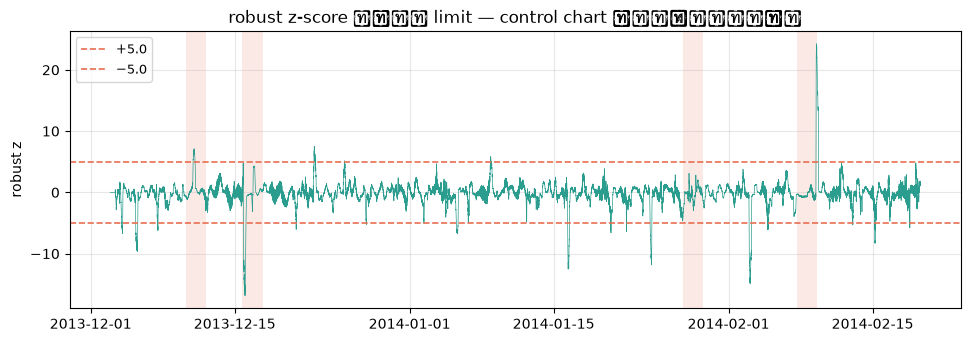

In [6]:
fig, ax = plt.subplots(figsize=(11.5, 3.6))
for a, b in lab_windows:
    ax.axvspan(np.datetime64(a), np.datetime64(b), color="#e76f51", alpha=0.15, lw=0)
ax.plot(ts, robust_z.to_numpy(), color="#2a9d8f", lw=0.5)
ax.axhline(Z_THR, color="#e76f51", ls="--", lw=1.2, label=f"+{Z_THR}")
ax.axhline(-Z_THR, color="#e76f51", ls="--", lw=1.2, label=f"−{Z_THR}")
ax.set_ylabel("robust z")
ax.set_title("robust z-score เทียบ limit — control chart อีกหน้าตาหนึ่ง")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

ตัว detector นี้คือญาติตรงไปตรงมาของ SPC: **Shewhart** ใช้ limit คงที่ ±3σ บน baseline นิ่ง, แบบที่เราใช้ปรับ limit ให้เคลื่อนตามเวลา และ EWMA chart (ถ่วงน้ำหนักค่าเก่า) ก็อยู่ตรงกลางระหว่างสองแบบนี้ — ถ้าหน่วยงานมี control chart อยู่แล้ว นี่คือจุดต่อยอดธรรมชาติก่อนแตะ ML

## 4. Window features + Isolation Forest

robust z มอง **ทีละจุด** — มันจึงมองไม่เห็นคุณภาพของ "ช่วง" ทางออกแบบ ML: รวมหน้าต่างเวลาเป็น **feature vector** แล้วให้โมเดลตัดสินทั้งหน้าต่าง

**Isolation Forest** ทำงานด้วยสัญชาตญาณง่าย ๆ: สุ่มแยกข้อมูลด้วยเส้นตัดไปเรื่อย ๆ — จุดที่ **แปลก** จะถูกแยกออกด้วยจำนวนตัด **น้อย** (อยู่ห่างฝูง) จุดที่อยู่ในฝูงหนาแน่นต้องตัดหลายครั้งกว่าจะโดดเดี่ยว เราไม่ต้องให้ label "ผิดปกติ" เลย — unsupervised

feature ต่อหน้าต่าง (12 จุด = 1 ชั่วโมง, ไม่ overlap): mean, std, **slope** (ความชันจาก linear regression บนลำดับภายในหน้าต่าง — จับ "กำลังไหล"), min, max

IsolationForest c=0.01, win=12: จับได้ 2/4 windows | flags = 228 | false alarms = 84


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPytho

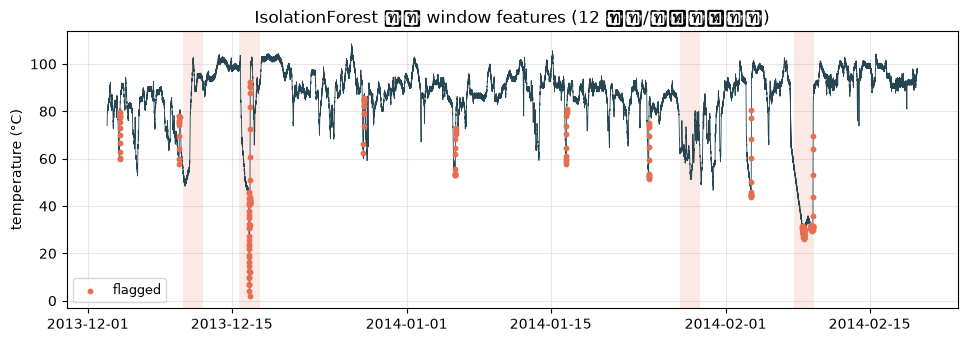

In [7]:
WIN = 12  # 12 จุด = 1 ชั่วโมง, ไม่ overlap
idx_local = np.arange(WIN)
n_win = len(v) // WIN
feats = np.empty((n_win, 5))
for i in range(n_win):
    seg = v[i * WIN:(i + 1) * WIN]
    feats[i] = (
        seg.mean(),
        seg.std(),
        np.polyfit(idx_local, seg, 1)[0],  # slope ภายในหน้าต่าง
        seg.min(),
        seg.max(),
    )

from sklearn.ensemble import IsolationForest

CONTAM = 0.01  # คาดว่า ~1% ของหน้าต่างผิดปกติ
iso = IsolationForest(contamination=CONTAM, random_state=42).fit(feats)
iso_pred = iso.predict(feats) == -1  # -1 = anomalous

if_flag = np.zeros(len(v), dtype=bool)
if_flag[: n_win * WIN] = np.repeat(iso_pred, WIN)
evaluate(if_flag, f"IsolationForest c={CONTAM}, win={WIN}")
plot_detections(if_flag, "IsolationForest บน window features (12 จุด/หน้าต่าง)")

เทียบกับ robust z:

- IF จับได้ **2/4** (หน้าต่างที่ 2 และ 4 — dropout ที่รุนแรง) แต่ **false alarms น้อยกว่ามาก** (~84 จุด vs ~473) เพราะตัดสินทั้งหน้าต่าง สัญญาณรบกวนจุดเดียวไม่ทำให้หน้าต่างโดน flag
- อีกครั้ง **หน้าต่างที่ 3 (ทางลาดช้า) หลุด** — slope ของหน้าต่างละ 1 ชั่วโมงระหว่างทางลาดช้าไม่ต่างจาก slope ปกติของซีรีส์พอจะโดดเด่น
- การเลือก `contamination` คือการบอกโมเดลล่วงหน้าว่า "คาดว่า ~1% ผิดปกติ" — ตัวเลขนี้กำหนดจำนวน flag โดยตรง เป็น hyperparameter ที่ต้องอธิบายให้ผู้ใช้ dashboard เข้าใจ ไม่ใช่ magic

## 5. One-Class SVM — เรียนรู้ "พรมแดนของความปกติ" จากช่วงที่ไว้ใจได้

Isolation Forest เรียนจากข้อมูลทั้งหมด (รวม anomaly ปนอยู่) — บางงานเราทำดีกว่านั้นได้: ในงานเมโทรโลยีเรารู้ว่าช่วงไหนเครื่อง "ปกติแน่นอน" (เพิ่งสอบเทียบ, ห้องควบคุมสภาพแวดล้อม) — นั่นคือ **ชุดอ้างอิงของเรา** เหมือน gauge reference

**One-Class SVM** เรียนรู้พรมแดนรอบข้อมูลช่วงปกติเท่านั้น แล้วให้คะแนนทุกจุดของซีรีส์: อยู่ในพรมแดน = ปกติ ออกนอก = anomalous ตัวแปรสำคัญ:

- `nu` — บน bound ของสัดส่วน training samples ที่จะตกนอกพรมแดน (ค่ามาก = พรมแดนกว้าง/ผ่อนปรน)
- `gamma` — ความ "โค้ง" ของ RBF kernel (ค่ามาก = พรมแดนรัดข้อมูลแน่น, ค่าน้อย = ราบเรียบ)

**ทางเลือกของช่วง train สำคัญกว่า hyperparameter** — ดูสองตัวเลือกก่อนเลือก:

In [8]:
train_first = ts < np.datetime64(lab_windows[0][0])  # ช่วงแรกก่อน anomaly แรก
train_mid = (ts > np.datetime64(lab_windows[1][1])) & (ts < np.datetime64(lab_windows[2][0]))  # ช่วงเงียบยาวกลางซีรีส์

print(f"ช่วงแรก (ก่อน anomaly แรก): {train_first.sum()} จุด, ค่า {v[train_first].min():.1f}–{v[train_first].max():.1f} °C")
print(f"ช่วงกลาง (ระหว่างหน้าต่าง 2 → 3): {train_mid.sum()} จุด, ค่า {v[train_mid].min():.1f}–{v[train_mid].max():.1f} °C")
print(f"ปกติทั้งหมด (นอก labeled): {v[~lab_mask].min():.1f}–{v[~lab_mask].max():.1f} °C")

ช่วงแรก (ก่อน anomaly แรก): 2126 จุด, ค่า 52.7–94.4 °C
ช่วงกลาง (ระหว่างหน้าต่าง 2 → 3): 11787 จุด, ค่า 51.3–108.5 °C
ปกติทั้งหมด (นอก labeled): 43.9–108.5 °C


ช่วงแรกสั้น (2 วัน) และ **ไม่ได้แทน envelope การทำงานจริง** — ใช้เป็น reference แล้วครึ่งซีรีส์จะโดนตรา "ผิดปกติ" อย่างไม่ยุติธรรม ช่วงกลางยาว ~6 สัปดาห์ ครอบคลุมพฤติกรรมปกติกว้างกว่ามาก จึงเลือกช่วงกลางเป็น "ช่วงปฏิบัติการปกติที่ไว้ใจได้"

OneClassSVM nu=0.01, gamma=0.05: จับได้ 4/4 windows | flags = 1350 | false alarms = 383


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPyt

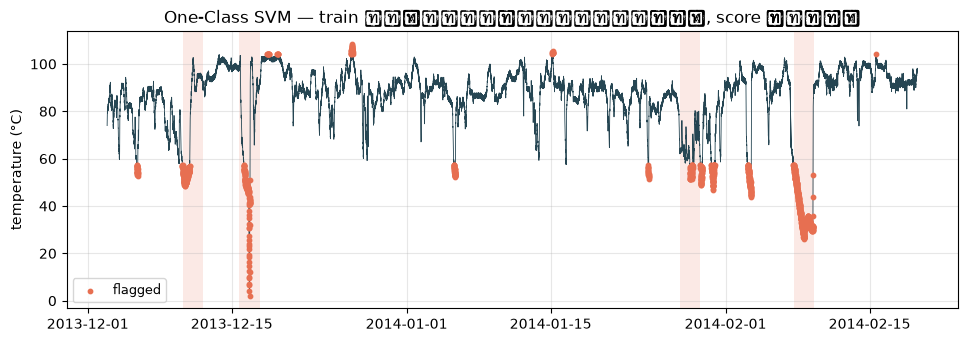

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

NU, GAMMA = 0.01, 0.05
ocsvm = make_pipeline(StandardScaler(), OneClassSVM(nu=NU, gamma=GAMMA))
ocsvm.fit(v[train_mid].reshape(-1, 1))  # fit เฉพาะ "ช่วงปกติ" — เหมือนการตั้ง gauge reference

oc_flag = ocsvm.predict(v.reshape(-1, 1)) == -1
evaluate(oc_flag, f"OneClassSVM nu={NU}, gamma={GAMMA}")
plot_detections(oc_flag, "One-Class SVM — train บนช่วงปกติยาวกลางซีรีส์, score ทั้งซีรีส์")

สรุปสาม detector บนซีรีส์จริง:

| detector | caught | false alarms | ข้อสังเกต |
|---|---|---|---|
| robust z (rolling, \|z\| > 5) | 3/4 | ~473 | เร็ว อธิบายง่าย แต่จุดต่อจุด เสี่ยง noise |
| Isolation Forest (win=12, c=0.01) | 2/4 | ~84 | นั่งฝั่ง "เข้มงวดน้อย flag น้อย" |
| One-Class SVM (nu=0.01, γ=0.05) | **4/4** | ~383 | จับครบเพราะ drift พาค่าออกนอก envelope ที่เรียนมา |

แต่อย่าเพิ่งฉลอง — ลองถามคำถามสำคัญ: detector เหล่านี้จะทำอย่างไรกับ **drift ช้า ๆ** ที่ไม่เคยพาค่าทะลุ envelope เดิม?

## 6. เคสยากที่ซ่อนอยู่: slow drift — ปิดท้ายอย่างตรงไปตรงมา

NAB กำกับเฉพาะ anomaly แบบฉับพลัน เราจึงสร้างเคส drift ขึ้นเองอย่าง deterministic (seed 42): ต่อท้ายซีรีส์ด้วยเส้นทางลาด **+0.05 °C ต่อจุด** นาน 400 จุด (~33 ชั่วโมง) พร้อม noise เบา ๆ — ความชันรวม +20 °C ตลอดช่วง แต่รายจุดเปลี่ยนแค่ 0.05 °C ซึ่งเล็กกว่า noise รายจุดเสียอีก

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/

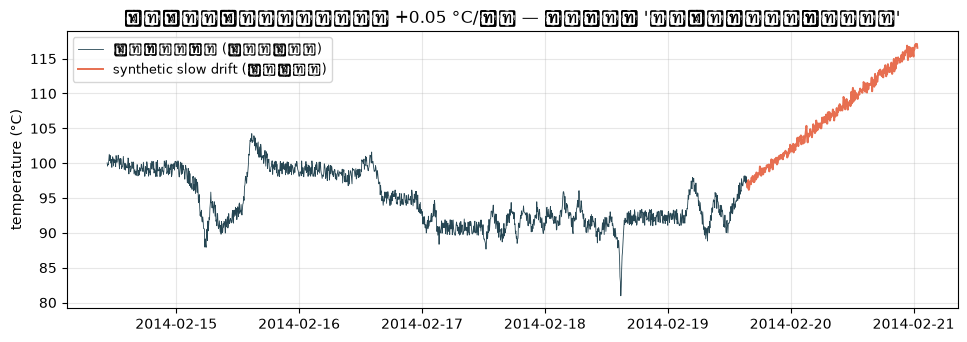

In [10]:
rng = np.random.default_rng(42)
RAMP_LEN = 400
RAMP_RATE = 0.05  # °C ต่อจุด — ช้าพอที่รายจุดจะจมอยู่ใน noise

drift_seg = v[-1] + RAMP_RATE * np.arange(1, RAMP_LEN + 1) + rng.normal(0.0, 0.5, RAMP_LEN)
v_drift = np.concatenate([v, drift_seg])

fig, ax = plt.subplots(figsize=(11.5, 3.6))
tail_n = 1_500
ax.plot(ts[-tail_n:], v[-tail_n:], color="#264653", lw=0.6, label="ข้อมูลจริง (ช่วงท้าย)")
ax.plot(ts[-1] + (np.arange(1, RAMP_LEN + 1) * np.timedelta64(5, "m")), drift_seg,
        color="#e76f51", lw=1.4, label="synthetic slow drift (ต่อท้าย)")
ax.set_ylabel("temperature (°C)")
ax.set_title("ต่อท้ายด้วยทางลาด +0.05 °C/จุด — ทุกจุดดู 'ใกล้เคียงเมื่อวาน'")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

ปล่อย detector จากสองหัวข้อก่อนหน้าลงบนช่วง drift แล้วนับจำนวน flag ที่ตก "ในช่วง drift" เท่านั้น:

In [11]:
# (1) robust z-score บนซีรีส์ที่มี drift
s_d = pl.Series(v_drift)
med_d = s_d.rolling_median(window_size=W, min_samples=W // 2)
mad_d = (s_d - med_d).abs().rolling_median(window_size=W, min_samples=W // 2) * 1.4826
z_d = ((s_d - med_d) / mad_d).fill_null(0.0).fill_nan(0.0).to_numpy()
z_flag_d = np.abs(z_d) > Z_THR
print(f"robust z        : flags ในช่วง drift = {z_flag_d[len(v):].sum()}/{RAMP_LEN} (max |z| = {np.abs(z_d[len(v):]).max():.2f})")

# (2) Isolation Forest — fit ค้างจากหัวข้อ 4, score หน้าต่างทั้งหมดของซีรีส์ใหม่
idx_local_d = np.arange(WIN)
n_win_d = len(v_drift) // WIN
feats_d = np.empty((n_win_d, 5))
for i in range(n_win_d):
    seg = v_drift[i * WIN:(i + 1) * WIN]
    feats_d[i] = (
        seg.mean(), seg.std(),
        np.polyfit(idx_local_d, seg, 1)[0],
        seg.min(), seg.max(),
    )
if_flag_d = np.zeros(len(v_drift), dtype=bool)
if_flag_d[: n_win_d * WIN] = np.repeat(iso.predict(feats_d) == -1, WIN)
print(f"Isolation Forest: flags ในช่วง drift = {if_flag_d[len(v):].sum()}/{RAMP_LEN}")

robust z        : flags ในช่วง drift = 0/400 (max |z| = 1.79)


Isolation Forest: flags ในช่วง drift = 0/400


ทั้งคู่ **เงียบทั้งช่วง drift** — เหตุผลตรงกับที่คาด:

- robust z: baseline แบบ trailing ไหลตามทางลาด (median ในหน้าต่างตามหลังค่าจริงอยู่ ~ครึ่งหน้าต่าง) residual คงที่ ~3.6 °C แต่ MAD ของหน้าต่างที่กำลังไหลก็บวมตาม — z ค้างที่ ~1.8
- Isolation Forest: slope ของหน้าต่าง 1 ชั่วโมง (~0.3 °C/ชม. ในหน่วยต่อจุด = 0.05) ยังอยู่ในกระจาย slope ปกติของซีรีส์ และ mean ที่ค่อย ๆ สูงก็ยังไม่ออกนอก envelope เดิมภายในหน้าต่างสั้น

ตัวจับ drift จริง ๆ ต้องมอง **สะสม** — นั่นคือหลักการเดียวกับ **CUSUM chart** ใน SPC: รวม residual ต่อเนื่อง เงื่อนไขเล็ก ๆ ที่ล้วนไปทางเดียวกันจะกองขึ้นจนทะลุ threshold แม้รายจุดจะเบา

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-pack

CUSUM           : flags ในช่วง drift = 29/400, alarm แรกที่ drift sample 14


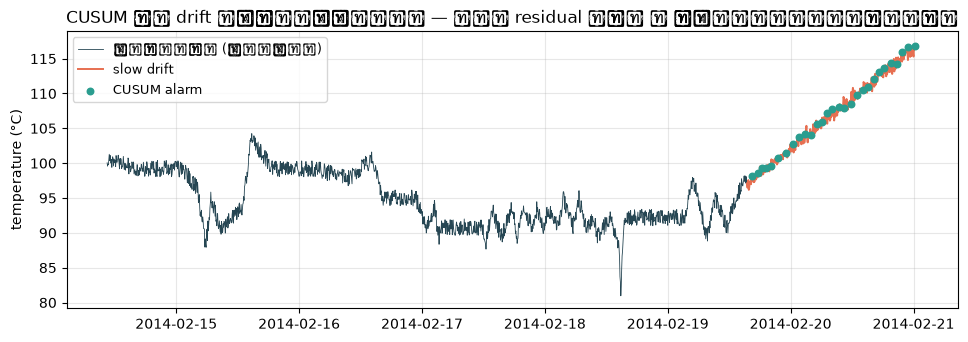

In [12]:
# (3) CUSUM-style detector บน residual จาก rolling baseline เดียวกัน
resid_d = v_drift - med_d.to_numpy()
sigma = float(np.nanmedian(mad_d.to_numpy()))
K, H = 0.5 * sigma, 5.0 * sigma  # slack และ threshold แบบ CUSUM มาตรฐาน

pos_sum = neg_sum = 0.0
cusum_flag = np.zeros(len(v_drift), dtype=bool)
for i in range(1, len(v_drift)):
    r = resid_d[i] if np.isfinite(resid_d[i]) else 0.0
    pos_sum = max(0.0, pos_sum + r - K)
    neg_sum = max(0.0, neg_sum - r - K)
    if pos_sum > H or neg_sum > H:
        cusum_flag[i] = True
        pos_sum = neg_sum = 0.0  # reset หลัง alarm

d_slice = slice(len(v), len(v_drift))
first_alarm = int(np.argmax(cusum_flag[d_slice])) + 1 if cusum_flag[d_slice].any() else None
print(f"CUSUM           : flags ในช่วง drift = {cusum_flag[d_slice].sum()}/{RAMP_LEN}, alarm แรกที่ drift sample {first_alarm}")

fig, ax = plt.subplots(figsize=(11.5, 3.6))
ax.plot(ts[-tail_n:], v[-tail_n:], color="#264653", lw=0.6, label="ข้อมูลจริง (ช่วงท้าย)")
ax.plot(ts[-1] + (np.arange(1, RAMP_LEN + 1) * np.timedelta64(5, "m")), drift_seg, color="#e76f51", lw=1.4, label="slow drift")
alarm_idx = len(v) + np.flatnonzero(cusum_flag[d_slice])
ax.scatter(ts[-1] + ((alarm_idx - len(v)) * np.timedelta64(5, "m")), v_drift[alarm_idx],
           s=22, color="#2a9d8f", zorder=3, label="CUSUM alarm")
ax.set_ylabel("temperature (°C)")
ax.set_title("CUSUM จับ drift ได้ตั้งแต่ต้นทาง — รวม residual เล็ก ๆ ที่ล้วงไปทางเดียวกัน")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 7. สรุปโมดูล

- anomaly มีสามชนิด (point / contextual / collective) และในงานเฝ้าเครื่องมือวัด รูปแบบสำคัญคือ sudden shift / dropout / slow drift — จับยากไม่เท่ากัน
- **rolling robust baseline (median + MAD, robust z)** คือญาติของ Shewhart/EWMA chart — จุดเริ่มที่เหมาะกว่า ML เสมอ และอธิบายต่อผู้ตรวจสอบได้
- **Isolation Forest** ตัดสินทั้งหน้าต่าง → false alarms น้อยลง; **One-Class SVM** เรียนพรมแดนจาก "ช่วงปกติที่ไว้ใจได้" เหมือนการตั้ง gauge reference — การเลือกช่วง train สำคัญกว่า hyperparameter
- **slow drift คือจุดบอดของ detector เกือบทั้งหมด** — baseline ปรับตัวไหลตาม, รายจุดจมใน noise; ต้องใช้มุมมองสะสม (CUSUM / slope test)
- กฎของโมดูลนี้: วัดผล detector ด้วย (caught windows, false alarms) สองตัวเลขพร้อมกันเสมอ — ตัวใดตัวหนึ่งอย่างเดียวโกหกได้